# classical_model_0

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F

from torchvision import datasets, transforms
from torch.utils.data import DataLoader

In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

Using device: cuda


In [ ]:
transform = transforms.Compose([
    transforms.ToTensor()
])

train_dataset = datasets.MNIST(
    root="./data",
    train=True,
    download=True,
    transform=transform
)

test_dataset = datasets.MNIST(
    root="./data",
    train=False,
    download=True,
    transform=transform
)

train_loader = DataLoader(train_dataset, batch_size=128, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=256, shuffle=False)

100%|██████████| 9.91M/9.91M [00:00<00:00, 21.0MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 487kB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 4.55MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 9.13MB/s]


In [ ]:
train_dataset

Dataset MNIST
    Number of datapoints: 60000
    Root location: ./data
    Split: Train
    StandardTransform
Transform: Compose(
               ToTensor()
           )

In [ ]:
one_set = next(iter(train_loader))
one_set[0].shape

torch.Size([128, 1, 28, 28])

In [ ]:
one_set = next(iter(test_loader))
one_set[0].shape

torch.Size([256, 1, 28, 28])

In [ ]:
one_set[0].dtype

torch.float32

In [ ]:
import matplotlib.pyplot as plt

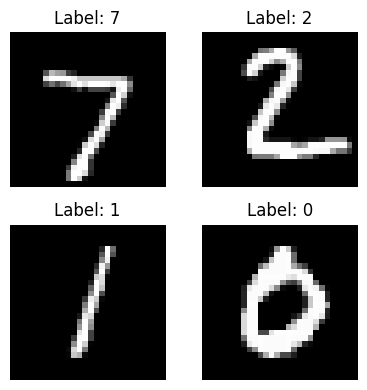

In [ ]:
images_batch, labels_batch = one_set

num_samples = 4
rows = 2
cols = 2

plt.figure(figsize=(cols * 2, rows * 2))

for i in range(num_samples):
  image = images_batch[i]
  label = labels_batch[i]

  plt.subplot(rows, cols, i + 1)
  plt.imshow(image.squeeze(), cmap="gray")
  plt.title(f"Label: {label.item()}")
  plt.axis("off")

plt.tight_layout()
plt.show()

In [ ]:
image.shape

torch.Size([1, 28, 28])

In [ ]:
images_batch.shape

torch.Size([256, 1, 28, 28])

In [ ]:
images_batch.size(0)

256

In [ ]:
images_batch.view(images_batch.size(0), -1).shape

torch.Size([256, 784])

In [ ]:
images_batch.view(images_batch.size(0), -1).shape

torch.Size([256, 784])

In [ ]:
class BSplineBasis(nn.Module):
  def __init__(self, num_basis=10, xmin=0.0, xmax=1.0):
    super().__init__()
    self.num_basis = num_basis
    self.register_buffer(
        "knots",
        torch.linspace(xmin, xmax, num_basis)
    )
    self.width = (xmax - xmin) / (num_basis - 1)

  def forward(self, x):
    # x: (B, in_dim)
    x = x.unsqueeze(-1)  # (B, in_dim, 1)
    diff = torch.abs(x - self.knots)
    basis = torch.clamp(1 - diff / self.width, min=0.0)
    return basis  # (B, in_dim, num_basis)

In [ ]:
layer = BSplineBasis()
images_flat = images_batch.view(images_batch.size(0), -1)
single_image = images_flat[0].unsqueeze(0)

In [ ]:
single_image.shape

torch.Size([1, 784])

In [ ]:
single_image.squeeze(0).reshape(28, 28).unsqueeze(dim=-1).shape

torch.Size([28, 28, 1])

In [ ]:
output = layer(single_image)

In [ ]:
output

tensor([[[1., 0., 0.,  ..., 0., 0., 0.],
         [1., 0., 0.,  ..., 0., 0., 0.],
         [1., 0., 0.,  ..., 0., 0., 0.],
         ...,
         [1., 0., 0.,  ..., 0., 0., 0.],
         [1., 0., 0.,  ..., 0., 0., 0.],
         [1., 0., 0.,  ..., 0., 0., 0.]]])

In [ ]:
output.shape

torch.Size([1, 784, 10])

Increasing number of basis (features per pixel, each pixel expanded into num_basis number of values):

- More expressive
- Can approximate more complex curves
- Higher resolution nonlinear modeling

but
- More memory
- More compute
- risk of overfitting
- Slower training

In [ ]:
layer = BSplineBasis()
images_flat = images_batch.view(images_batch.size(0), -1)
output = layer(images_flat)

In [ ]:
output.shape

torch.Size([256, 784, 10])

**out = (basis_vals * coeff).sum(-1)** is the edge function which calculates:

$\phi_{ij}(x) = \sum_k c_{ijk} B_k(x)$

model0 edge function:

$\phi_{ij}(x) = \sum_k c_{ijk} B_k(x)$

k = number of basis

B(x) = spline basis

c = learnable coefficient

In [ ]:
class KANLayer(nn.Module):
  def __init__(self, in_dim, out_dim, num_basis=10):
    super().__init__()
    self.in_dim = in_dim
    self.out_dim = out_dim
    self.num_basis = num_basis

    self.basis = BSplineBasis(num_basis)

    self.coeff = nn.Parameter(
        torch.randn(in_dim, out_dim, num_basis) * 0.01
    )

    self.bias = nn.Parameter(torch.zeros(out_dim))
    self.scale = nn.Parameter(torch.ones(out_dim))

  def forward(self, x):
    basis_vals = self.basis(x)
    basis_vals = basis_vals.unsqueeze(2)
    coeff = self.coeff.unsqueeze(0)

    out = (basis_vals * coeff).sum(-1)
    out = out.sum(1)

    out = self.scale * out + self.bias

    return out

In [ ]:
kan_layer_instance = KANLayer(in_dim=784, out_dim=64, num_basis=10).to(device)
single_image_on_device = single_image.to(device)
kan_output = kan_layer_instance(single_image_on_device)

In [ ]:
print("Output from KANLayer:")
print(kan_output)
print("\nShape of KANLayer output:")
print(kan_output.shape)

Output from KANLayer:
tensor([[ 0.1448, -0.3409,  0.2044, -0.2480, -0.0696,  0.0897,  0.3178, -0.0823,
         -0.1812, -0.1344, -0.3737,  0.1547,  0.0742,  0.0826,  0.2787,  0.2859,
         -0.2218, -0.3199,  0.1112,  0.0099,  0.1035, -0.2354, -0.2264, -0.1509,
          0.0396, -0.2184,  0.3747, -0.0251, -0.1113,  0.1657,  0.7489,  0.0922,
          0.0215,  0.0358, -0.1590,  0.4388, -0.1337, -0.3266,  0.1774,  0.1693,
          0.1531,  0.1121, -0.2756, -0.2985,  0.2371,  0.0778,  0.3425, -0.1021,
         -0.4581, -0.0178, -0.3215, -0.1606,  0.1051, -0.1017,  0.0068, -0.1017,
          0.1976,  0.0875, -0.0557, -0.4838, -0.1097,  0.2616, -0.1948,  0.2235]],
       device='cuda:0', grad_fn=<AddBackward0>)

Shape of KANLayer output:
torch.Size([1, 64])


In [ ]:
class KANModel(nn.Module):
  def __init__(self):
    super().__init__()

    self.kan1 = KANLayer(784, 64, num_basis=8)
    self.norm1 = nn.LayerNorm(64)

    self.kan2 = KANLayer(64, 32, num_basis=8)
    self.norm2 = nn.LayerNorm(32)

    self.fc = nn.Linear(32, 10)

  def forward(self, x):
    x = x.view(x.size(0), -1)

    x = self.kan1(x)
    x = self.norm1(x)
    x = F.relu(x)

    x = self.kan2(x)
    x = self.norm2(x)
    x = F.relu(x)

    x = self.fc(x)
    return x

In [ ]:
model_instance = KANModel().to(device)
single_image_on_device = single_image.to(device)
model_output = model_instance(single_image_on_device)

print("Output from KANModel:")
print(model_output)
print("\nShape of KANModel output:")
print(model_output.shape)

Output from KANModel:
tensor([[-0.5265, -0.5821,  0.6258,  0.1865, -0.1033,  0.0048, -0.6104,  0.8780,
         -0.3063, -0.3472]], device='cuda:0', grad_fn=<AddmmBackward0>)

Shape of KANModel output:
torch.Size([1, 10])


In [ ]:
model_classical_0 = KANModel().to(device)

criterion = nn.CrossEntropyLoss()
optimizer = optim.AdamW(model_classical_0.parameters(), lr=3e-4)

In [ ]:
print(model_classical_0)

KANModel(
  (kan1): KANLayer(
    (basis): BSplineBasis()
  )
  (norm1): LayerNorm((64,), eps=1e-05, elementwise_affine=True)
  (kan2): KANLayer(
    (basis): BSplineBasis()
  )
  (norm2): LayerNorm((32,), eps=1e-05, elementwise_affine=True)
  (fc): Linear(in_features=32, out_features=10, bias=True)
)


In [ ]:
total_params = sum(p.numel() for p in model_classical_0.parameters() if p.requires_grad)
print(f"Total trainable parameters in model_classical_0: {total_params:,}")

Total trainable parameters in model_classical_0: 418,506


In [ ]:
def train_epoch(model, loader):
  model.train()
  total_loss = 0
  correct = 0
  total = 0

  for images, labels in loader:
    images = images.to(device)
    labels = labels.to(device)

    optimizer.zero_grad()

    outputs = model(images)
    loss = criterion(outputs, labels)

    loss.backward()
    optimizer.step()

    total_loss += loss.item()

    _, predicted = outputs.max(1)
    total += labels.size(0)
    correct += predicted.eq(labels).sum().item()

  return total_loss / len(loader), 100. * correct / total

In [ ]:
def evaluate(model, loader):
  model.eval()

  total_loss = 0
  correct = 0
  total = 0

  with torch.no_grad():
    for images, labels in loader:
      images = images.to(device)
      labels = labels.to(device)

      outputs = model(images)
      loss = criterion(outputs, labels)

      total_loss += loss.item()

      _, predicted = outputs.max(1)
      total += labels.size(0)
      correct += predicted.eq(labels).sum().item()

  avg_loss = total_loss / len(loader)
  accuracy = 100. * correct / total

  return avg_loss, accuracy

In [ ]:
epochs = 15
best_test_acc = 0.0

res0 = {
    "train_loss": [],
    "train_acc": [],
    "test_acc": [],
    "test_loss": []
}

for epoch in range(epochs):
  train_loss, train_acc = train_epoch(model_classical_0, train_loader)
  test_loss, test_acc = evaluate(model_classical_0, test_loader)

  res0["train_loss"].append(train_loss)
  res0["train_acc"].append(train_acc)
  res0["test_loss"].append(test_loss)
  res0["test_acc"].append(test_acc)

  print(f"Epoch {epoch+1:02d} | "
        f"Loss: {train_loss:.4f} | "
        f"Train Acc: {train_acc:.2f}% | "
        f"Test Acc: {test_acc:.2f}%")

  if test_acc > best_test_acc:
      best_test_acc = test_acc
      torch.save(model_classical_0.state_dict(), 'best_model_classical_0.pth')
      print(f"  --> Model saved with new best test accuracy: {best_test_acc:.2f}%")

Epoch 01 | Loss: 0.8500 | Train Acc: 82.49% | Test Acc: 93.48%
  --> Model saved with new best test accuracy: 93.48%
Epoch 02 | Loss: 0.2442 | Train Acc: 94.57% | Test Acc: 93.89%
  --> Model saved with new best test accuracy: 93.89%
Epoch 03 | Loss: 0.1450 | Train Acc: 96.53% | Test Acc: 94.85%
  --> Model saved with new best test accuracy: 94.85%
Epoch 04 | Loss: 0.1014 | Train Acc: 97.45% | Test Acc: 95.03%
  --> Model saved with new best test accuracy: 95.03%
Epoch 05 | Loss: 0.0701 | Train Acc: 98.30% | Test Acc: 94.85%
Epoch 06 | Loss: 0.0559 | Train Acc: 98.60% | Test Acc: 95.19%
  --> Model saved with new best test accuracy: 95.19%
Epoch 07 | Loss: 0.0475 | Train Acc: 98.77% | Test Acc: 95.33%
  --> Model saved with new best test accuracy: 95.33%
Epoch 08 | Loss: 0.0328 | Train Acc: 99.13% | Test Acc: 95.12%
Epoch 09 | Loss: 0.0348 | Train Acc: 99.04% | Test Acc: 94.43%
Epoch 10 | Loss: 0.0329 | Train Acc: 99.05% | Test Acc: 95.73%
  --> Model saved with new best test accuracy:

In [ ]:
import matplotlib.pyplot as plt
import random
import math
import torch

In [ ]:
def visualize_predictions(model, dataset, device, num_samples=16):
  model.eval()

  indices = random.sample(range(len(dataset)), num_samples)

  cols = int(math.sqrt(num_samples))
  rows = math.ceil(num_samples / cols)

  plt.figure(figsize=(cols * 2, rows * 2))

  for i, idx in enumerate(indices):
    image, label = dataset[idx]
    input_img = image.unsqueeze(0).to(device)

    with torch.no_grad():
      output = model(input_img)
      pred = output.argmax(dim=1).item()

    plt.subplot(rows, cols, i + 1)
    plt.imshow(image.squeeze(), cmap="gray")

    color = "green" if pred == label else "red"
    plt.title(f"P:{pred} | T:{label}", color=color, fontsize=9)
    plt.axis("off")

  plt.tight_layout()
  plt.show()

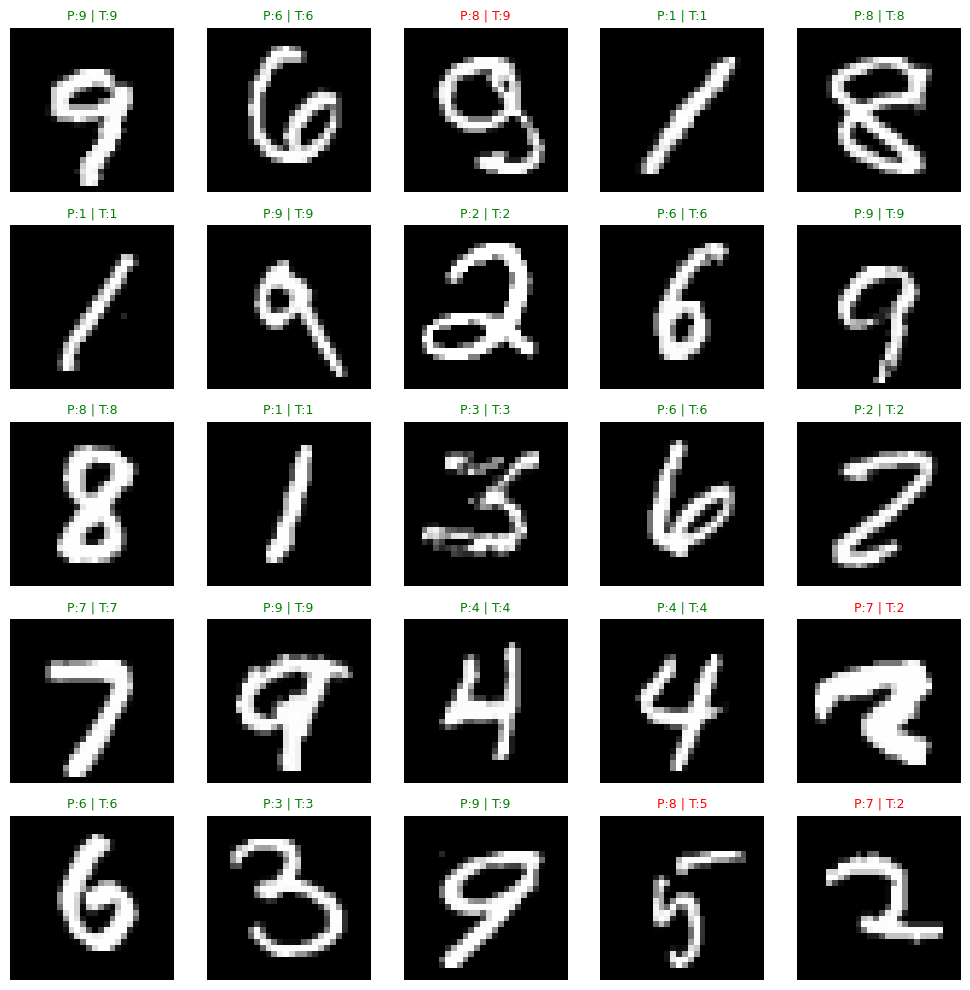

In [ ]:
visualize_predictions(model_classical_0, test_dataset, device, num_samples=25)

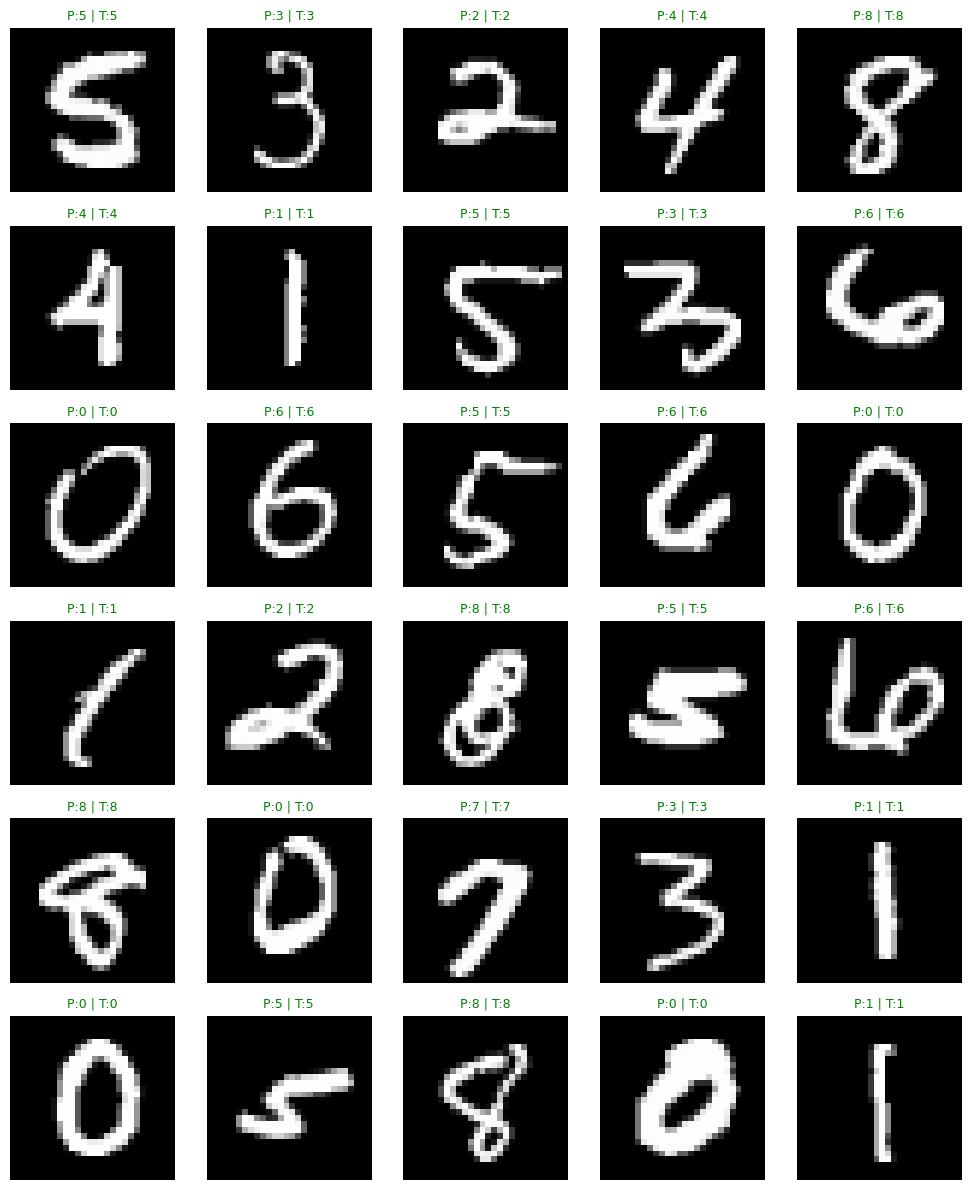

In [ ]:
visualize_predictions(model_classical_0, test_dataset, device, num_samples=30)

In [ ]:
def final_evaluation(model, loader, device):
  model.eval()

  criterion = nn.CrossEntropyLoss()

  total_loss = 0
  correct = 0
  total = 0

  num_classes = 10
  confusion = torch.zeros(num_classes, num_classes)

  with torch.no_grad():
    for images, labels in loader:
      images = images.to(device)
      labels = labels.to(device)

      outputs = model(images)
      loss = criterion(outputs, labels)

      total_loss += loss.item()

      preds = outputs.argmax(dim=1)

      total += labels.size(0)
      correct += (preds == labels).sum().item()

      for t, p in zip(labels.view(-1), preds.view(-1)):
          confusion[t.long(), p.long()] += 1

  avg_loss = total_loss / len(loader)
  accuracy = 100. * correct / total

  print(f"\nFinal Test Loss: {avg_loss:.4f}")
  print(f"Final Test Accuracy: {accuracy:.2f}%\n")

  print("Per-class accuracy:")
  for i in range(num_classes):
      class_acc = 100. * confusion[i, i] / confusion[i].sum()
      print(f"Class {i}: {class_acc:.2f}%")

  plt.figure(figsize=(8,6))
  plt.imshow(confusion.numpy(), interpolation='nearest')
  plt.title("Confusion Matrix")
  plt.colorbar()
  plt.xlabel("Predicted")
  plt.ylabel("True")
  plt.xticks(range(num_classes))
  plt.yticks(range(num_classes))
  plt.show()

  return accuracy


Final Test Loss: 0.1950
Final Test Accuracy: 94.99%

Per-class accuracy:
Class 0: 98.78%
Class 1: 99.38%
Class 2: 92.93%
Class 3: 97.03%
Class 4: 92.67%
Class 5: 90.36%
Class 6: 94.15%
Class 7: 95.43%
Class 8: 94.25%
Class 9: 93.86%


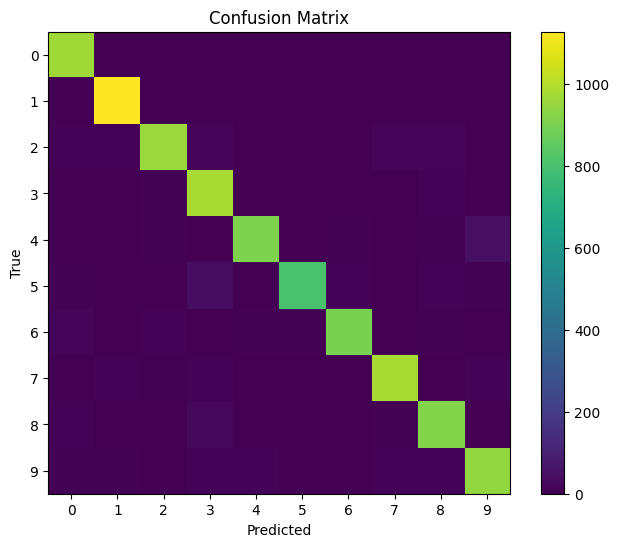

94.99

In [ ]:
final_evaluation(model_classical_0, test_loader, device)

# classical_model_1

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
import math

from torchvision import datasets, transforms
from torch.utils.data import DataLoader

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

Using device: cuda


In [ ]:
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.1307,), (0.3081,))
])

train_dataset = datasets.MNIST(
    root="./data",
    train=True,
    download=True,
    transform=transform
)

test_dataset = datasets.MNIST(
    root="./data",
    train=False,
    download=True,
    transform=transform
)

In [ ]:
train_loader = DataLoader(train_dataset, batch_size=128, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=256, shuffle=False)

 model1 edge function:

$y = w_b\,\text{Linear}(\mathrm{SiLU}(x)) + w_s\,\text{Spline}(x)$

w_b = base scale

 w_s = spline scale

spline(x) = torch.einsum('bik,iok->bo', basis_vals, self.coeff) (weighted sum of spline basis functions)

In [ ]:
class KANLayerV1(nn.Module):
  def __init__(self, in_dim, out_dim, num_basis=10, xmin=-3.0, xmax=3.0):
    super().__init__()

    self.in_dim = in_dim
    self.out_dim = out_dim
    self.num_basis = num_basis

    self.register_buffer("knots", torch.linspace(xmin, xmax, num_basis))
    self.width = (xmax - xmin) / (num_basis - 1)

    std = 1.0 / math.sqrt(in_dim)

    self.coeff = nn.Parameter(
        torch.empty(in_dim, out_dim, num_basis).uniform_(-std, std)
    )

    self.base_weight = nn.Parameter(
        torch.empty(out_dim, in_dim).uniform_(-std, std)
    )
    self.base_bias = nn.Parameter(
        torch.empty(out_dim).uniform_(-std, std)
    )

    self.base_activation = nn.SiLU()

    self.base_scale = nn.Parameter(torch.ones(out_dim))
    self.spline_scale = nn.Parameter(torch.ones(out_dim))

  def forward(self, x):
    base = F.linear(self.base_activation(x), self.base_weight, self.base_bias)
    base = self.base_scale * base

    x_expanded = x.unsqueeze(-1)
    diff = torch.abs(x_expanded - self.knots)
    basis_vals = torch.clamp(1 - diff / self.width, min=0.0)

    spline = torch.einsum('bik,iok->bo', basis_vals, self.coeff)
    spline = self.spline_scale * spline

    return base + spline

In [ ]:
class KANModelV1(nn.Module):
  def __init__(self):
    super().__init__()
    self.kan1 = KANLayerV1(784, 128, num_basis=10)
    self.ln1 = nn.LayerNorm(128)

    self.kan2 = KANLayerV1(128, 64, num_basis=10)
    self.ln2 = nn.LayerNorm(64)

    self.kan3 = KANLayerV1(64, 10, num_basis=10)

  def forward(self, x):
    x = x.view(x.size(0), -1)
    x = self.kan1(x)
    x = self.ln1(x)
    x = self.kan2(x)
    x = self.ln2(x)
    x = self.kan3(x)
    return x

In [ ]:
model_classical_1 = KANModelV1().to(device)

criterion = nn.CrossEntropyLoss()
optimizer = optim.AdamW(model_classical_1.parameters(), lr=1e-3)

In [ ]:
total_params = sum(p.numel() for p in model_classical_1.parameters() if p.requires_grad)
print(f"Total trainable parameters in model_classical_1: {total_params:,}")

Total trainable parameters in model_classical_1: 1,202,014


In [ ]:
epochs = 15
best_test_acc = 0.0

res1 = {
    "train_loss": [],
    "train_acc": [],
    "test_acc": [],
    "test_loss": []
}

for epoch in range(epochs):
  train_loss, train_acc = train_epoch(model_classical_1, train_loader)
  test_loss, test_acc = evaluate(model_classical_1, test_loader)

  res1["train_loss"].append(train_loss)
  res1["train_acc"].append(train_acc)
  res1["test_acc"].append(test_acc)
  res1["test_loss"].append(test_loss)

  print(f"Epoch {epoch+1:02d} | "
        f"Loss: {train_loss:.4f} | "
        f"Train Acc: {train_acc:.2f}% | "
        f"Test Acc: {test_acc:.2f}%")

  if test_acc > best_test_acc:
      best_test_acc = test_acc
      torch.save(model_classical_1.state_dict(), 'best_model_classical_1.pth')
      print(f"  --> Model saved with new best test accuracy: {best_test_acc:.2f}%")

Epoch 01 | Loss: 0.3441 | Train Acc: 90.63% | Test Acc: 95.35%
  --> Model saved with new best test accuracy: 95.35%
Epoch 02 | Loss: 0.1126 | Train Acc: 96.61% | Test Acc: 96.68%
  --> Model saved with new best test accuracy: 96.68%
Epoch 03 | Loss: 0.0729 | Train Acc: 97.68% | Test Acc: 96.62%
Epoch 04 | Loss: 0.0504 | Train Acc: 98.43% | Test Acc: 97.17%
  --> Model saved with new best test accuracy: 97.17%
Epoch 05 | Loss: 0.0380 | Train Acc: 98.72% | Test Acc: 96.85%
Epoch 06 | Loss: 0.0290 | Train Acc: 99.07% | Test Acc: 97.26%
  --> Model saved with new best test accuracy: 97.26%
Epoch 07 | Loss: 0.0255 | Train Acc: 99.17% | Test Acc: 97.75%
  --> Model saved with new best test accuracy: 97.75%
Epoch 08 | Loss: 0.0208 | Train Acc: 99.33% | Test Acc: 97.35%
Epoch 09 | Loss: 0.0220 | Train Acc: 99.25% | Test Acc: 97.64%
Epoch 10 | Loss: 0.0182 | Train Acc: 99.37% | Test Acc: 97.87%
  --> Model saved with new best test accuracy: 97.87%
Epoch 11 | Loss: 0.0162 | Train Acc: 99.45% | 


Final Test Loss: 0.0928
Final Test Accuracy: 97.56%

Per-class accuracy:
Class 0: 98.98%
Class 1: 99.30%
Class 2: 96.90%
Class 3: 96.63%
Class 4: 96.64%
Class 5: 96.30%
Class 6: 98.64%
Class 7: 98.44%
Class 8: 97.23%
Class 9: 96.23%


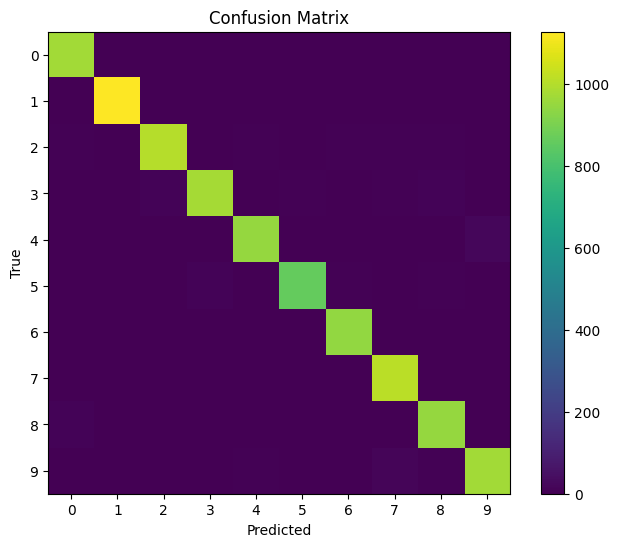

97.56

In [ ]:
final_evaluation(model_classical_1, test_loader, device)

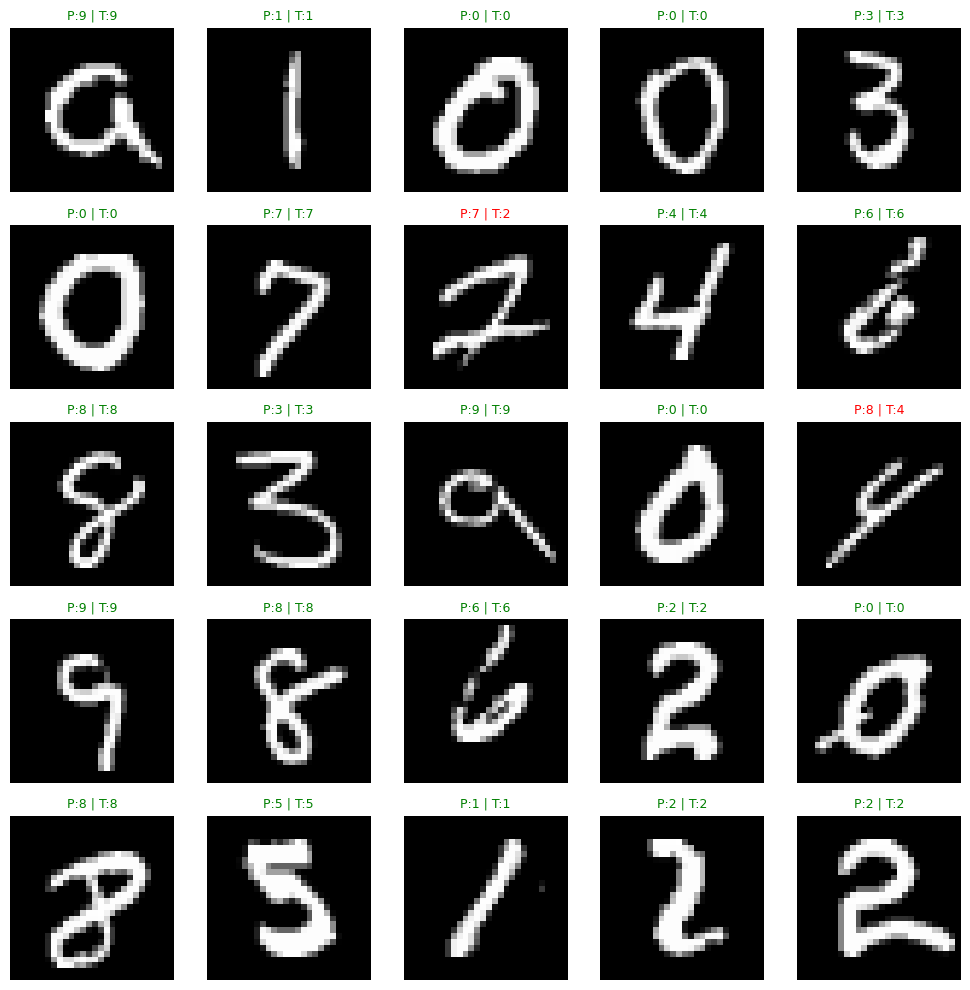

In [ ]:
visualize_predictions(model_classical_1, test_dataset, device, num_samples=25)

# comparison

In [ ]:
import matplotlib.pyplot as plt

def plot_comparison(res0, res1,
                    label0="Model 0",
                    label1="Model 1"):

  epochs = range(1, len(res0["test_loss"]) + 1)

  fig, axes = plt.subplots(2, 1, figsize=(8, 10))

  axes[0].plot(epochs, res0["test_loss"], label=f"{label0} Test Loss")
  axes[0].plot(epochs, res1["test_loss"], label=f"{label1} Test Loss")
  axes[0].set_title("Test Loss Comparison")
  axes[0].set_xlabel("Epoch")
  axes[0].set_ylabel("Loss")
  axes[0].legend()
  axes[0].grid(True)

  axes[1].plot(epochs, res0["test_acc"], label=f"{label0} Test Accuracy")
  axes[1].plot(epochs, res1["test_acc"], label=f"{label1} Test Accuracy")
  axes[1].set_title("Test Accuracy Comparison")
  axes[1].set_xlabel("Epoch")
  axes[1].set_ylabel("Accuracy (%)")
  axes[1].legend()
  axes[1].grid(True)

  plt.tight_layout()
  plt.show()

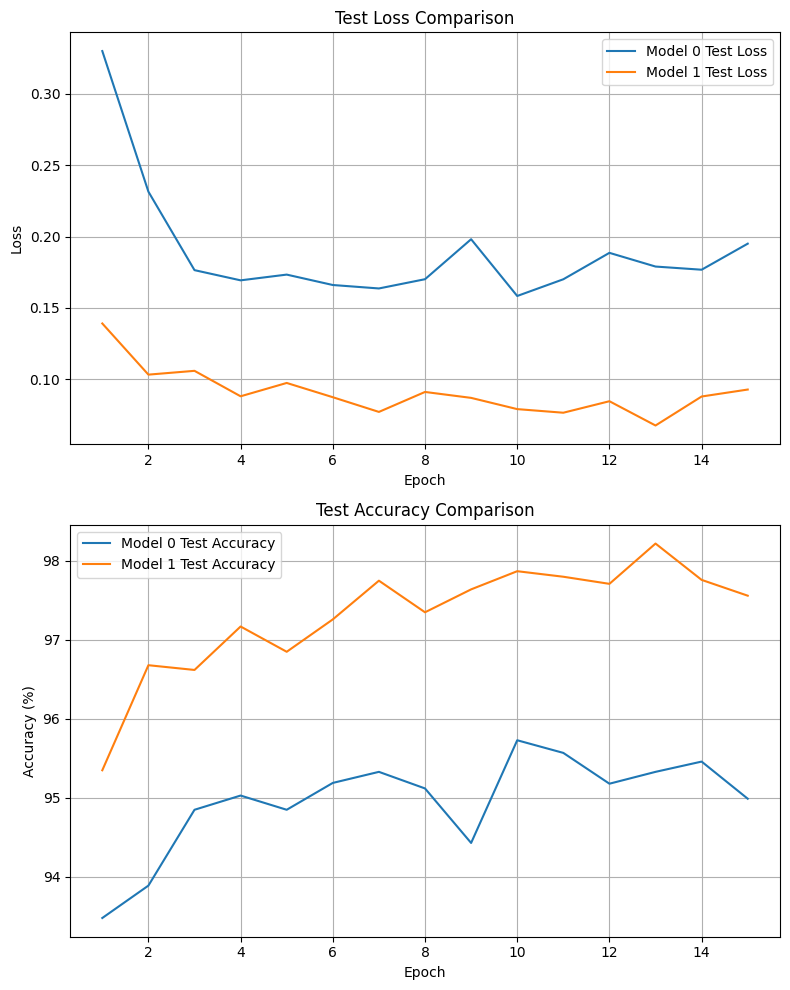

In [ ]:
plot_comparison(res0, res1)

In [ ]:
!pip install thop -q

In [ ]:
import torch
import time
import pandas as pd
from thop import profile

def count_parameters(model):
  return sum(p.numel() for p in model.parameters() if p.requires_grad)

def compute_macs(model, input_size=(1,1,28,28)):
  dummy = torch.randn(input_size).to(device)
  macs, _ = profile(model, inputs=(dummy,), verbose=False)
  return macs

def measure_inference_time(model, input_size=(1,1,28,28), runs=200):
  model.eval()
  dummy = torch.randn(input_size).to(device)

  for _ in range(20):
    _ = model(dummy)

  if device.type == "cuda":
    torch.cuda.synchronize()

  start = time.time()

  for _ in range(runs):
    _ = model(dummy)

  if device.type == "cuda":
    torch.cuda.synchronize()

  end = time.time()

  return (end - start) / runs

params0 = count_parameters(model_classical_0)
params1 = count_parameters(model_classical_1)

macs0 = compute_macs(model_classical_0)
macs1 = compute_macs(model_classical_1)

inf0 = measure_inference_time(model_classical_0)
inf1 = measure_inference_time(model_classical_1)

acc0 = res0["test_acc"][-1]
acc1 = res1["test_acc"][-1]

comparison_df = pd.DataFrame({
  "Metric": [
    "Parameters (M)",
    "MACs (M)",
    "Inference Time (ms)",
    "Final Test Accuracy (%)"
  ],
  "KAN v0": [
    params0 / 1e6,
    macs0 / 1e6,
    inf0 * 1000,
    acc0
],
  "KAN v1": [
    params1 / 1e6,
    macs1 / 1e6,
    inf1 * 1000,
    acc1
  ]
})

In [ ]:
comparison_df

,Metric,KAN v0,KAN v1
0,Parameters (M),0.418506,1.202014
1,MACs (M),0.000704,0.000768
2,Inference Time (ms),1.027068,1.518185
3,Final Test Accuracy (%),94.990000,97.560000


# classical_model_2

 model2 edge function: base linear + Chebyshev polynomial

 $y = \sum W\,\sigma(x) + b + \sum_{d} c_d\,T_d(\tanh(x))$

 T_d = Chebyshev polynomial of degree d

c_d = trainable coefficient for each polynomial basis

 tanh(x) = input normalization step

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
import math
import time
import pandas as pd
from thop import profile

def count_parameters(model):
  return sum(p.numel() for p in model.parameters() if p.requires_grad)

def compute_macs(model, input_size=(1,1,28,28)):
  dummy = torch.randn(input_size).to(device)
  macs, _ = profile(model, inputs=(dummy,), verbose=False)
  return macs

def measure_inference_time(model, input_size=(1,1,28,28), runs=200):
  model.eval()
  dummy = torch.randn(input_size).to(device)

  for _ in range(20):
    _ = model(dummy)

  if device == "cuda":
    torch.cuda.synchronize()

  start = time.time()

  for _ in range(runs):
    _ = model(dummy)

  if device == "cuda":
    torch.cuda.synchronize()

  end = time.time()

  return (end - start) / runs


class ChebyKANLayer(nn.Module):
  def __init__(self, in_features, out_features, degree=3):
    super().__init__()
    self.in_features = in_features
    self.out_features = out_features
    self.degree = degree

    self.base_activation = nn.SiLU()
    self.base_weight = nn.Parameter(torch.Tensor(out_features, in_features))
    self.base_bias = nn.Parameter(torch.Tensor(out_features))


    self.poly_weight = nn.Parameter(torch.Tensor(out_features, in_features * (degree + 1)))

    self.reset_parameters()

  def reset_parameters(self):
    nn.init.kaiming_uniform_(self.base_weight, a=math.sqrt(5))
    nn.init.zeros_(self.base_bias)
    nn.init.xavier_normal_(self.poly_weight)

  def forward(self, x):
    base_out = F.linear(self.base_activation(x), self.base_weight, self.base_bias)

    x_norm = torch.tanh(x)

    basis = [torch.ones_like(x_norm), x_norm]
    for i in range(2, self.degree + 1):
      basis.append(2 * x_norm * basis[-1] - basis[-2])

    basis_tensor = torch.cat(basis, dim=1)

    poly_out = F.linear(basis_tensor, self.poly_weight)

    return base_out + poly_out

class KANModelV2(nn.Module):
  def __init__(self):
    super().__init__()
    self.kan1 = ChebyKANLayer(784, 64, degree=3)
    self.ln1 = nn.LayerNorm(64)

    self.kan2 = ChebyKANLayer(64, 32, degree=3)
    self.ln2 = nn.LayerNorm(32)

    self.kan3 = ChebyKANLayer(32, 10, degree=3)

  def forward(self, x):
    x = x.view(x.size(0), -1)
    x = self.kan1(x)
    x = self.ln1(x)
    x = self.kan2(x)
    x = self.ln2(x)
    x = self.kan3(x)
    return x

model_classical_2 = KANModelV2().to(device)

criterion = nn.CrossEntropyLoss()
optimizer = optim.AdamW(model_classical_2.parameters(), lr=1e-3)

total_params_2 = sum(p.numel() for p in model_classical_2.parameters() if p.requires_grad)
print(f"Total trainable parameters in KAN v2: {total_params_2:,}")

epochs = 15
best_test_acc_2 = 0.0

res2 = {
    "train_loss": [], "train_acc": [],
    "test_acc": [], "test_loss": []
}

print("\n--- Training KAN v2 (Chebyshev KAN) ---")
for epoch in range(epochs):
  train_loss, train_acc = train_epoch(model_classical_2, train_loader)
  test_loss, test_acc = evaluate(model_classical_2, test_loader)

  res2["train_loss"].append(train_loss)
  res2["train_acc"].append(train_acc)
  res2["test_loss"].append(test_loss)
  res2["test_acc"].append(test_acc)

  print(f"Epoch {epoch+1:02d} | Loss: {train_loss:.4f} | Train Acc: {train_acc:.2f}% | Test Acc: {test_acc:.2f}%")

  if test_acc > best_test_acc_2:
    best_test_acc_2 = test_acc
    torch.save(model_classical_2.state_dict(), 'best_model_classical_2.pth')

params2 = count_parameters(model_classical_2)
macs2 = compute_macs(model_classical_2)
inf2 = measure_inference_time(model_classical_2)
acc2 = res2["test_acc"][-1]

new_row = pd.DataFrame({
  "Metric": [
    "Parameters (M)",
    "MACs (M)",
    "Inference Time (ms)",
    "Final Test Accuracy (%)"
  ],
  "KAN v2 (Chebyshev)": [
    params2 / 1e6,
    macs2 / 1e6,
    inf2 * 1000,
    acc2
  ]
})

comparison_df = comparison_df.merge(new_row, on="Metric")
print("\n--- Final Comparison ---")
display(comparison_df)


Total trainable parameters in KAN v2: 263,018

--- Training KAN v2 (Chebyshev KAN) ---
Epoch 01 | Loss: 0.4199 | Train Acc: 88.36% | Test Acc: 94.50%
Epoch 02 | Loss: 0.1625 | Train Acc: 95.17% | Test Acc: 96.23%
Epoch 03 | Loss: 0.1161 | Train Acc: 96.50% | Test Acc: 96.17%
Epoch 04 | Loss: 0.0962 | Train Acc: 97.09% | Test Acc: 96.85%
Epoch 05 | Loss: 0.0794 | Train Acc: 97.56% | Test Acc: 96.77%
Epoch 06 | Loss: 0.0679 | Train Acc: 97.97% | Test Acc: 97.23%
Epoch 07 | Loss: 0.0597 | Train Acc: 98.08% | Test Acc: 96.90%
Epoch 08 | Loss: 0.0533 | Train Acc: 98.32% | Test Acc: 97.08%
Epoch 09 | Loss: 0.0494 | Train Acc: 98.45% | Test Acc: 97.36%
Epoch 10 | Loss: 0.0454 | Train Acc: 98.57% | Test Acc: 97.40%
Epoch 11 | Loss: 0.0369 | Train Acc: 98.79% | Test Acc: 97.08%
Epoch 12 | Loss: 0.0377 | Train Acc: 98.77% | Test Acc: 97.66%
Epoch 13 | Loss: 0.0377 | Train Acc: 98.75% | Test Acc: 97.44%
Epoch 14 | Loss: 0.0287 | Train Acc: 99.10% | Test Acc: 97.50%
Epoch 15 | Loss: 0.0299 | Train

,Metric,KAN v0,KAN v1,KAN v2 (Chebyshev)_x,KAN v2 (Chebyshev)_y
0,Parameters (M),0.418506,1.202014,0.263018,0.263018
1,MACs (M),0.000704,0.000768,0.000384,0.000384
2,Inference Time (ms),1.027068,1.518185,2.208345,1.275876
3,Final Test Accuracy (%),94.990000,97.560000,97.300000,97.190000


# model0 vs model1 vs model2

In [ ]:
def plot_comparison(all_results):
  fig, axes = plt.subplots(2, 1, figsize=(10, 10))

  for model_name, results in all_results.items():
    epochs = range(1, len(results["test_loss"]) + 1)
    axes[0].plot(epochs, results["test_loss"], label=f"{model_name} Test Loss")
  axes[0].set_title("Test Loss Comparison Across Models")
  axes[0].set_xlabel("Epoch")
  axes[0].set_ylabel("Loss")
  axes[0].legend()
  axes[0].grid(True)

  for model_name, results in all_results.items():
    epochs = range(1, len(results["test_acc"]) + 1)
    axes[1].plot(epochs, results["test_acc"], label=f"{model_name} Test Accuracy")
  axes[1].set_title("Test Accuracy Comparison Across Models")
  axes[1].set_xlabel("Epoch")
  axes[1].set_ylabel("Accuracy (%)")
  axes[1].legend()
  axes[1].grid(True)

  plt.tight_layout()
  plt.show()

all_model_results = {
    'KAN v0': res0,
    'KAN v1': res1,
    'KAN v2': res2
}

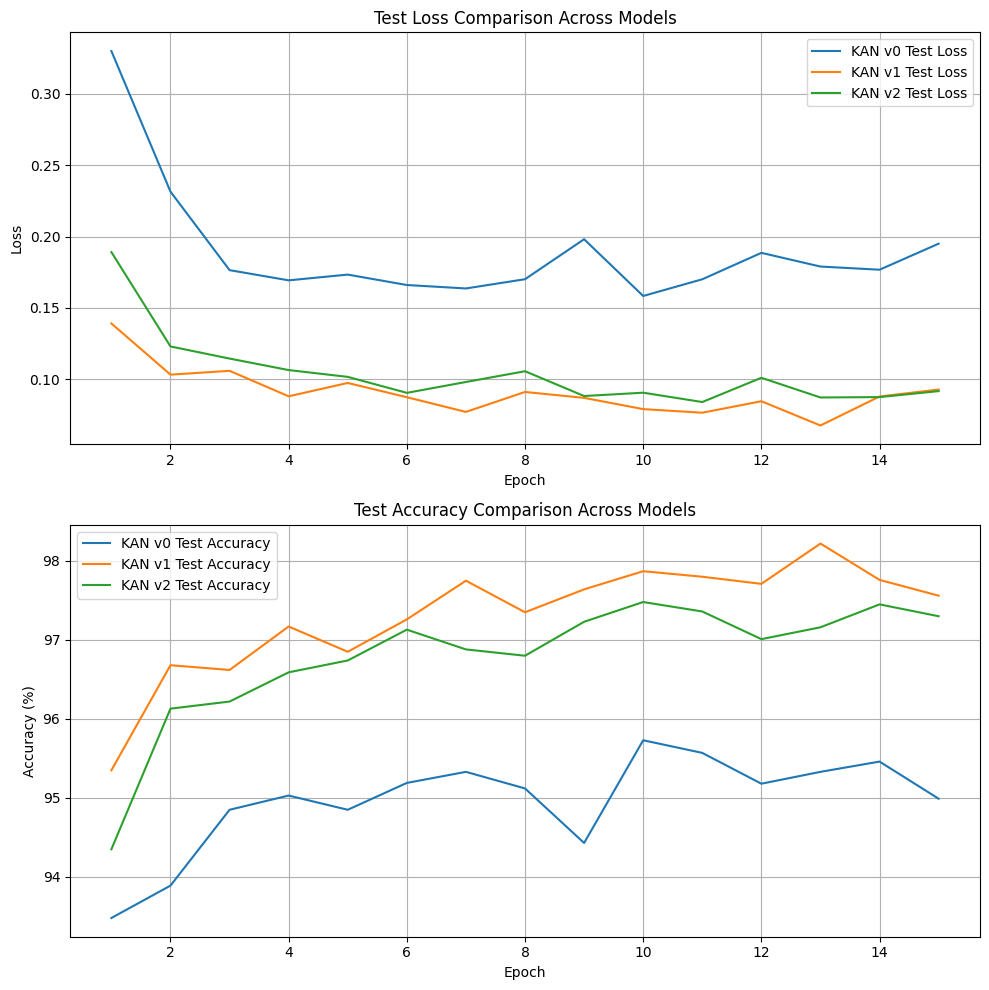

In [ ]:
plot_comparison(all_model_results)

# Convolutional KAN

convolutional KAN model edge function:

$
y = \mathrm{Conv}(\mathrm{SiLU}(x), W_b)
+ \mathrm{Conv}\big([T_0(\tanh x), T_1(\tanh x), \dots, T_D(\tanh x)], W_{\text{poly}}\big)
$

Conv(SiLU(x),W_b​) = convolution applied to the activated input (base linear component)

Conv(⋅,W_poly​) = convolution applied to the polynomial basis feature maps

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
import math
import matplotlib.pyplot as plt

from torchvision import datasets, transforms
from torch.utils.data import DataLoader

In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.1307,), (0.3081,))
])

train_dataset = datasets.MNIST(root="./data", train=True, download=True, transform=transform)
test_dataset = datasets.MNIST(root="./data", train=False, download=True, transform=transform)

train_loader = DataLoader(train_dataset, batch_size=128, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=256, shuffle=False)

Using device: cuda


In [ ]:
class ChebyKANConv2d(nn.Module):
  def __init__(self, in_channels, out_channels, kernel_size, stride=1, padding=0, degree=3):
    super().__init__()
    self.in_channels = in_channels
    self.out_channels = out_channels
    self.kernel_size = kernel_size
    self.stride = stride
    self.padding = padding
    self.degree = degree

    self.base_activation = nn.SiLU()


    self.base_weight = nn.Parameter(torch.Tensor(out_channels, in_channels, kernel_size, kernel_size))
    self.base_bias = nn.Parameter(torch.Tensor(out_channels))
    self.poly_weight = nn.Parameter(torch.Tensor(out_channels, in_channels * (degree + 1), kernel_size, kernel_size))

    self.reset_parameters()

  def reset_parameters(self):
    nn.init.kaiming_uniform_(self.base_weight, a=math.sqrt(5))
    nn.init.zeros_(self.base_bias)
    nn.init.xavier_normal_(self.poly_weight)

  def forward(self, x):
    base_out = F.conv2d(self.base_activation(x), self.base_weight, self.base_bias, self.stride, self.padding)

    x_norm = torch.tanh(x)

    basis = [torch.ones_like(x_norm), x_norm]
    for i in range(2, self.degree + 1):
      basis.append(2 * x_norm * basis[-1] - basis[-2])

    basis_tensor = torch.cat(basis, dim=1)

    poly_out = F.conv2d(basis_tensor, self.poly_weight, bias=None, stride=self.stride, padding=self.padding)

    return base_out + poly_out

In [ ]:
class ChebyKANLayer(nn.Module):
  def __init__(self, in_features, out_features, degree=3):
    super().__init__()
    self.in_features = in_features
    self.out_features = out_features
    self.degree = degree

    self.base_activation = nn.SiLU()
    self.base_weight = nn.Parameter(torch.Tensor(out_features, in_features))
    self.base_bias = nn.Parameter(torch.Tensor(out_features))
    self.poly_weight = nn.Parameter(torch.Tensor(out_features, in_features * (degree + 1)))

    self.reset_parameters()

  def reset_parameters(self):
    nn.init.kaiming_uniform_(self.base_weight, a=math.sqrt(5))
    nn.init.zeros_(self.base_bias)
    nn.init.xavier_normal_(self.poly_weight)

  def forward(self, x):
    base_out = F.linear(self.base_activation(x), self.base_weight, self.base_bias)
    x_norm = torch.tanh(x)

    basis = [torch.ones_like(x_norm), x_norm]
    for i in range(2, self.degree + 1):
        basis.append(2 * x_norm * basis[-1] - basis[-2])

    basis_tensor = torch.cat(basis, dim=1)
    poly_out = F.linear(basis_tensor, self.poly_weight)
    return base_out + poly_out

In [ ]:
class ConvChebyKAN(nn.Module):
  def __init__(self):
    super().__init__()
    self.conv1 = ChebyKANConv2d(in_channels=1, out_channels=16, kernel_size=3, padding=1, degree=3)
    self.bn1 = nn.BatchNorm2d(16)
    self.pool1 = nn.MaxPool2d(2) # 28x28 -> 14x14
    self.conv2 = ChebyKANConv2d(in_channels=16, out_channels=32, kernel_size=3, padding=1, degree=3)
    self.bn2 = nn.BatchNorm2d(32)
    self.pool2 = nn.MaxPool2d(2) # 14x14 -> 7x7
    self.flatten_dim = 32 * 7 * 7 # 1568
    self.fc1 = ChebyKANLayer(self.flatten_dim, 64, degree=3)
    self.ln1 = nn.LayerNorm(64)
    self.fc2 = ChebyKANLayer(64, 10, degree=3)

  def forward(self, x):
    x = self.conv1(x)
    x = self.bn1(x)
    x = self.pool1(x)
    x = self.conv2(x)
    x = self.bn2(x)
    x = self.pool2(x)
    x = x.view(x.size(0), -1)
    x = self.fc1(x)
    x = self.ln1(x)
    x = self.fc2(x)
    return x

In [ ]:
chebyKANConvModel = ConvChebyKAN().to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.AdamW(chebyKANConvModel.parameters(), lr=1e-3, weight_decay=1e-4)

In [ ]:
def train_epoch(model, loader):
  model.train()
  total_loss, correct, total = 0, 0, 0

  for images, labels in loader:
    images, labels = images.to(device), labels.to(device)

    optimizer.zero_grad()
    outputs = model(images)
    loss = criterion(outputs, labels)
    loss.backward()
    optimizer.step()

    total_loss += loss.item()
    _, predicted = outputs.max(1)
    total += labels.size(0)
    correct += predicted.eq(labels).sum().item()

  return total_loss / len(loader), 100. * correct / total

def evaluate(model, loader):
  model.eval()
  total_loss, correct, total = 0, 0, 0

  with torch.no_grad():
    for images, labels in loader:
      images, labels = images.to(device), labels.to(device)
      outputs = model(images)
      loss = criterion(outputs, labels)

      total_loss += loss.item()
      _, predicted = outputs.max(1)
      total += labels.size(0)
      correct += predicted.eq(labels).sum().item()

  return total_loss / len(loader), 100. * correct / total

In [ ]:
epochs = 15
history = {"train_loss": [], "train_acc": [], "test_loss": [], "test_acc": []}

print(f"Total parameters: {sum(p.numel() for p in chebyKANConvModel.parameters() if p.requires_grad):,}")
print("Starting Training...")

for epoch in range(epochs):
  train_loss, train_acc = train_epoch(chebyKANConvModel, train_loader)
  test_loss, test_acc = evaluate(chebyKANConvModel, test_loader)

  history["train_loss"].append(train_loss)
  history["train_acc"].append(train_acc)
  history["test_loss"].append(test_loss)
  history["test_acc"].append(test_acc)

  print(f"Epoch {epoch+1:02d}/{epochs} | "
        f"Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.2f}% | "
        f"Test Loss: {test_loss:.4f} | Test Acc: {test_acc:.2f}%")

Total parameters: 529,066
Starting Training...
Epoch 01/15 | Train Loss: 0.2372 | Train Acc: 93.81% | Test Loss: 0.0538 | Test Acc: 98.39%
Epoch 02/15 | Train Loss: 0.0459 | Train Acc: 98.67% | Test Loss: 0.0387 | Test Acc: 98.71%
Epoch 03/15 | Train Loss: 0.0308 | Train Acc: 99.11% | Test Loss: 0.0350 | Test Acc: 98.82%
Epoch 04/15 | Train Loss: 0.0241 | Train Acc: 99.28% | Test Loss: 0.0370 | Test Acc: 98.77%
Epoch 05/15 | Train Loss: 0.0183 | Train Acc: 99.44% | Test Loss: 0.0568 | Test Acc: 98.17%
Epoch 06/15 | Train Loss: 0.0165 | Train Acc: 99.47% | Test Loss: 0.0360 | Test Acc: 98.86%
Epoch 07/15 | Train Loss: 0.0128 | Train Acc: 99.61% | Test Loss: 0.0487 | Test Acc: 98.47%
Epoch 08/15 | Train Loss: 0.0110 | Train Acc: 99.68% | Test Loss: 0.0459 | Test Acc: 98.60%
Epoch 09/15 | Train Loss: 0.0091 | Train Acc: 99.72% | Test Loss: 0.0369 | Test Acc: 98.81%
Epoch 10/15 | Train Loss: 0.0082 | Train Acc: 99.75% | Test Loss: 0.0364 | Test Acc: 98.83%
Epoch 11/15 | Train Loss: 0.0066 

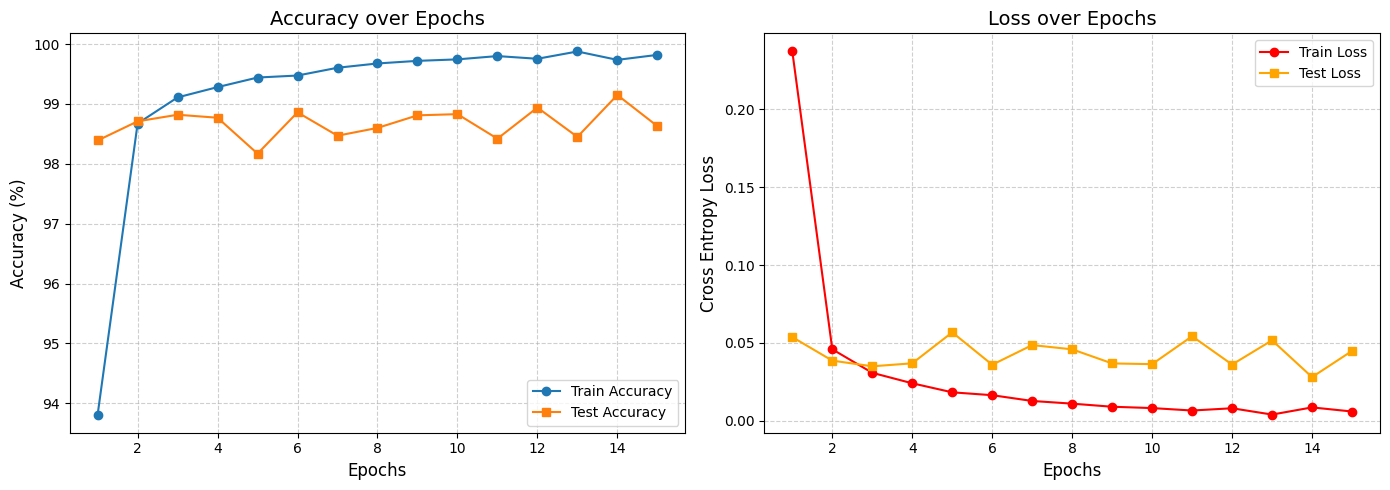

In [ ]:
def plot_learning_curves(history):
  epochs_range = range(1, len(history["train_loss"]) + 1)

  fig, axes = plt.subplots(1, 2, figsize=(14, 5))

  axes[0].plot(epochs_range, history["train_acc"], label="Train Accuracy", marker='o')
  axes[0].plot(epochs_range, history["test_acc"], label="Test Accuracy", marker='s')
  axes[0].set_title("Accuracy over Epochs", fontsize=14)
  axes[0].set_xlabel("Epochs", fontsize=12)
  axes[0].set_ylabel("Accuracy (%)", fontsize=12)
  axes[0].legend()
  axes[0].grid(True, linestyle='--', alpha=0.6)

  axes[1].plot(epochs_range, history["train_loss"], label="Train Loss", marker='o', color='red')
  axes[1].plot(epochs_range, history["test_loss"], label="Test Loss", marker='s', color='orange')
  axes[1].set_title("Loss over Epochs", fontsize=14)
  axes[1].set_xlabel("Epochs", fontsize=12)
  axes[1].set_ylabel("Cross Entropy Loss", fontsize=12)
  axes[1].legend()
  axes[1].grid(True, linestyle='--', alpha=0.6)

  plt.tight_layout()
  plt.show()

plot_learning_curves(history)

In [ ]:
def count_parameters(model):
  return sum(p.numel() for p in model.parameters() if p.requires_grad)

def compute_macs(model, input_size=(1,1,28,28)):
  dummy = torch.randn(input_size).to(device)
  macs, _ = profile(model, inputs=(dummy,), verbose=False)
  return macs

def measure_inference_time(model, input_size=(1,1,28,28), runs=200):
  model.eval()
  dummy = torch.randn(input_size).to(device)

  for _ in range(20):
    _ = model(dummy)

  if device == "cuda":
    torch.cuda.synchronize()

  start = time.time()

  for _ in range(runs):
    _ = model(dummy)

  if device == "cuda":
    torch.cuda.synchronize()

  end = time.time()

  return (end - start) / runs

In [ ]:
count_parameters(chebyKANConvModel)

529066

In [ ]:
compute_macs(chebyKANConvModel)

75520.0

In [ ]:
measure_inference_time(chebyKANConvModel)

0.001415255069732666

# KAN Models Performance Summary

All models were trained for **15 epochs on MNIST** using **AdamW optimization**.

---

# Models Implemented

## 1. Classical Model 0 - KAN v0 (Spline-Based KAN)

This is the **baseline KAN architecture** that follows the original KAN idea:  
instead of fixed activations, **learnable functions are placed on edges**.

Each edge function is parameterized using **B-spline basis functions**.

### Edge Function
$
\phi_{ij}(x) = \sum_{k} c_{ijk} B_k(x)
$

Where:

- \(B_k(x)\) = spline basis function  
- \(c_{ijk}\) = learnable coefficients  
- \(k\) = number of spline bases

### Architecture
```
784 → KAN(64) → LayerNorm → ReLU
    → KAN(32) → LayerNorm → ReLU
    → Linear(10)
```

### Characteristics

- Fully spline-based nonlinear representation
- Demonstrates the **core idea of KAN**
- Higher parameter count due to **basis expansion per edge**

---

# 2. Classical Model 1 - KAN v1 (Hybrid Linear + Spline KAN)

This version improves KAN v0 by adding a **linear base path alongside the spline function**.

Instead of relying purely on splines, the model learns a **combination of linear and spline representations**.

### Edge Function

$
y = w_b \cdot \text{Linear}(\text{SiLU}(x)) + w_s \cdot \text{Spline}(x)
$

Where:

- \(w_b\) = base linear scale
- \(w_s\) = spline scale

### Architecture
```
784 → KAN(128) → LayerNorm
    → KAN(64) → LayerNorm
    → KAN(10)
```

### Characteristics

- Hybrid **linear + spline representation**
- Improves **training stability**
- Higher parameter count
- Better accuracy than pure spline KAN

---

# 3. Classical Model 2 - KAN v2 (Chebyshev Polynomial KAN)

Instead of spline basis functions, this model uses **Chebyshev polynomials**.

Polynomial basis functions provide:

- better **numerical stability**
- smoother approximations
- fewer parameters

### Edge Function

$
y = \sum W\,\sigma(x) + b + \sum_d c_d\,T_d(\tanh(x))
$

Where:

- \(T_d(x)\) = Chebyshev polynomial of degree \(d\)
- \(c_d\) = trainable polynomial coefficient
- \(\tanh(x)\) = input normalization

### Architecture
```
784 → ChebyKAN(64) → LayerNorm
    → ChebyKAN(32) → LayerNorm
    → ChebyKAN(10)
```

### Characteristics

- Uses **orthogonal polynomial basis**
- Lower parameter count
- Efficient approximation of nonlinear functions
- Strong accuracy with **lowest compute cost**

---

# 4. Convolutional KAN - ConvChebyKAN

This model integrates **convolutional feature extraction with Chebyshev KAN layers**.

Instead of flattening images immediately, spatial information is preserved using convolution.

### Edge Function

$
y =
Conv(\text{SiLU}(x), W_b)
+
Conv([T_0(\tanh x), T_1(\tanh x), …, T_D(\tanh x)], W_{poly})
$

Where:

- \(W_b\) = base convolution weights
- \(W_{poly}\) = polynomial convolution weights

### Characteristics

- Combines **CNN inductive bias with KAN nonlinearities**
- Exploits **spatial structure of images**
- Highest accuracy among all models
- Higher compute due to convolution operations

---

# Key Metrics

The following table summarizes the performance of all models after training.

| Metric                      | KAN v0   | KAN v1   | KAN v2 (Chebyshev) | ConvChebyKAN |
|-----------------------------|----------|----------|--------------------|--------------|
| **Parameters (M)**          | 0.418506 | 1.202014 | 0.263018           | 0.529066     |
| **MACs (M)**                | 0.000704 | 0.000768 | 0.000384           | 0.07552      |
| **Inference Time (ms)**     | 1.027068 | 1.518185 | 1.275876           | 1.415255     |
| **Final Test Accuracy (%)** | 94.99    | 97.56    | 97.19              | **98.63**    |
| **Final Test Loss**         | 0.1950   | 0.0928   | 0.0299             | 0.0449       |

### Metric Definitions

- **Parameters (M)**  
  Total trainable parameters (in millions).

- **MACs (M)**  
  Multiply-Accumulate operations required for one forward pass.

- **Inference Time (ms)**  
  Average time required to process one sample.

- **Final Test Accuracy (%)**  
  Classification accuracy on the MNIST test set.

- **Final Test Loss**  
  Cross-entropy loss after the final epoch.

---

# Observations

### Model Efficiency

- **KAN v2 (Chebyshev)** achieves strong performance with the **lowest compute cost**.
- **KAN v1** improves accuracy but increases parameter count.

### Accuracy

- **ConvChebyKAN achieves the highest accuracy (98.63%)**, likely due to convolution capturing spatial structure in images.

### Trade-offs

| Model | Strength | Limitation |
|------|------|------|
| KAN v0 | Demonstrates pure KAN concept | Lower accuracy |
| KAN v1 | Hybrid representation improves performance | Large parameter count |
| KAN v2 | Efficient polynomial representation | Slightly lower accuracy than conv |
| ConvChebyKAN | Best accuracy | Higher compute cost |
